In [2]:
import os
import numpy as np
import pandas as pd

file_path = './test_results_v4_rev1.xlsx'

df_raw = pd.read_excel(file_path, engine='openpyxl')
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("Unnamed:")]

/tmp/ipykernel_3536087/3135255018.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(len(all_noise_labels), 1))


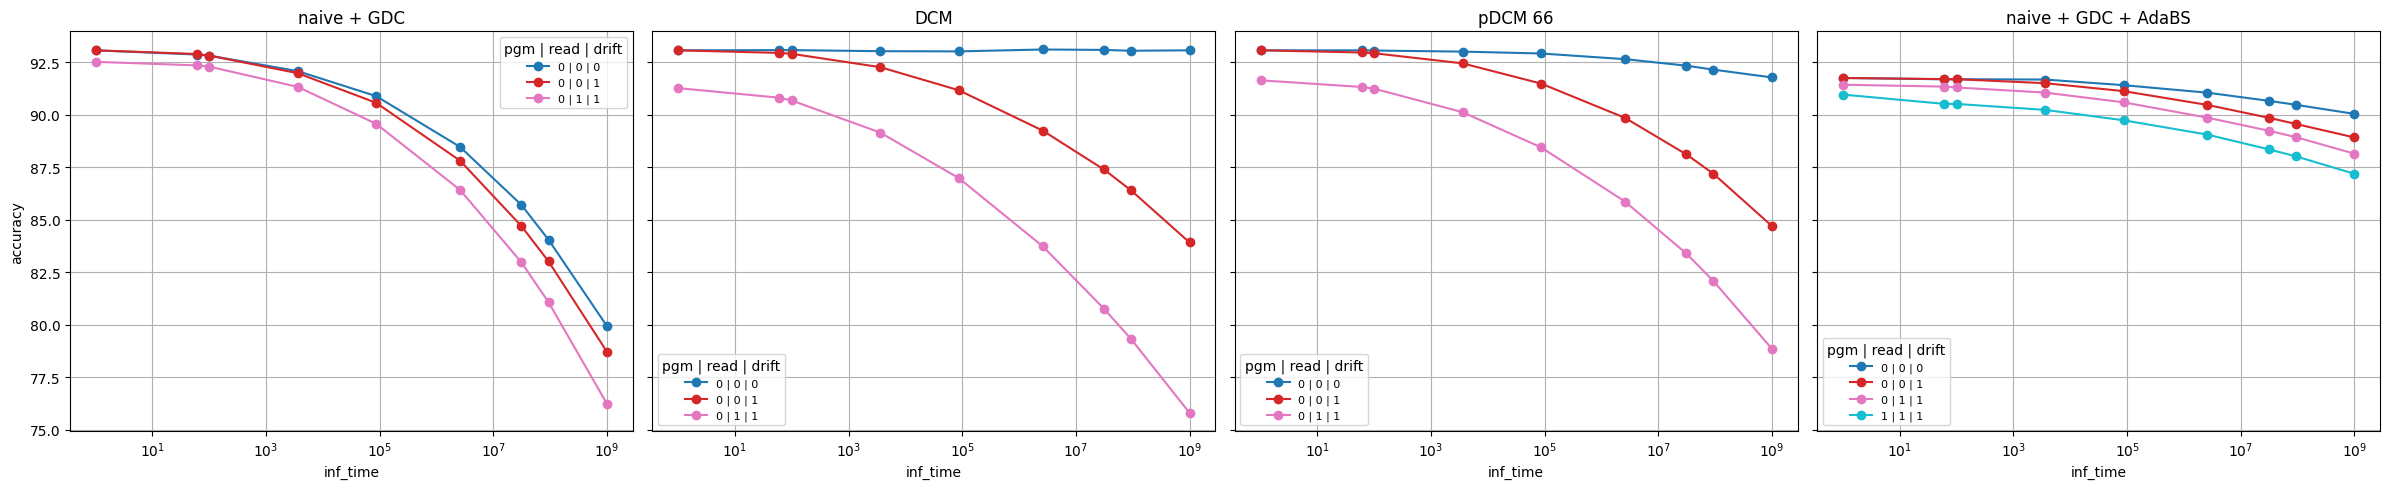

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_filtered = df_raw.copy()
df_filtered = df_filtered[df_filtered['model_type'] == 'vanilla']
df_filtered = df_filtered[df_filtered['GDC'] == 'on']

def is_missing_like(series):
    return series.isna() | series.astype(str).str.lower().isin(['nan', 'none', '-'])

conditions = [
    (
        'naive + GDC',
        (df_filtered['mapping_method'] == 'naive')
        & (df_filtered['alpha'] == 'GDC')
        & is_missing_like(df_filtered['distortion_f'])
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'DCM',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'pDCM 66',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.333')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'naive + GDC + AdaBS',
        (df_filtered['mapping_method'] == 'naive')
        & (df_filtered['alpha'] == 'GDC')
        & is_missing_like(df_filtered['distortion_f'])
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
]

noise_cols = ['pgm_noise_scale', 'read_noise_scale', 'drift_noise_scale']
condition_dfs = []

for condition_name, condition_mask in conditions:
    condition_df = df_filtered[condition_mask].copy()
    condition_df['condition_name'] = condition_name
    condition_df['noise_label'] = condition_df[noise_cols].astype(str).agg(' | '.join, axis=1)
    condition_dfs.append(condition_df)

plot_df = pd.concat(condition_dfs, ignore_index=True)

all_noise_labels = sorted(plot_df['noise_label'].dropna().unique())
cmap = plt.cm.get_cmap('tab10', max(len(all_noise_labels), 1))
color_map = {label: cmap(i) for i, label in enumerate(all_noise_labels)}

fig, axes = plt.subplots(1, len(conditions), figsize=(6 * len(conditions), 5), sharey=True, squeeze=False)

for idx, (condition_name, _) in enumerate(conditions):
    ax = axes[0][idx]
    subset = plot_df[plot_df['condition_name'] == condition_name].sort_values('inf_time')

    for noise_label in all_noise_labels:
        line_df = subset[subset['noise_label'] == noise_label].sort_values('inf_time')
        if line_df.empty:
            continue

        ax.plot(
            line_df['inf_time'],
            line_df['accuracy'],
            marker='o',
            label=noise_label,
            color=color_map[noise_label]
        )

    ax.set_title(condition_name)
    ax.set_xlabel('inf_time')
    ax.grid(True)

    if subset['inf_time'].gt(0).any():
        ax.set_xscale('log')

    if idx == 0:
        ax.set_ylabel('accuracy')

    if not subset.empty:
        ax.legend(title='pgm | read | drift', fontsize=8)

plt.tight_layout()
plt.show()
